In [1]:
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
DATA_DIR = Path(r"E:\Credit Risk Assessment System\dataset\processed_models")
PROJECT_DIR = Path(r"E:\Credit Risk Assessment System")

In [2]:
try:
    X_train = pd.read_csv(DATA_DIR / "X_train_unscaled.csv")
    X_test = pd.read_csv(DATA_DIR / "X_test_unscaled.csv")
    y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze()
    y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze()
except FileNotFoundError as exc:
    raise FileNotFoundError("Run 05_Data_Preprocessing_for_Modeling.ipynb first") from exc

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Feature count:", X_train.shape[1])
display(pd.DataFrame({
    "train_%": y_train.value_counts(normalize=True).mul(100).round(2),
    "test_%": y_test.value_counts(normalize=True).mul(100).round(2),
}))

Train: (452296, 149) Test: (61503, 149)
Feature count: 149


,train_%,test_%
TARGET,,
0,50.0,91.93
1,50.0,8.07


In [3]:
model = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    criterion="gini",
    class_weight="balanced",
)
print(model)

DecisionTreeClassifier(class_weight='balanced', random_state=42)


In [4]:
start = time.time()
model.fit(X_train, y_train)
training_time = time.time() - start

print(f"Model trained in {training_time:.2f} seconds")
print(f"Tree depth: {model.get_depth()}, Leaves: {model.get_n_leaves()}")

Model trained in 27.10 seconds
Tree depth: 50, Leaves: 22797


In [5]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)[:, 1]

print("Sample predicted classes:", y_test_pred[:5])
print("Sample predicted probabilities (TARGET=1):", y_test_proba[:5].round(3))

Sample predicted classes: [0 0 0 0 0]
Sample predicted probabilities (TARGET=1): [0. 0. 0. 0. 0.]


In [6]:
def evaluate(y_true, y_pred, y_proba=None) -> dict:
    """Compute standard classification metrics."""
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
    }
    if y_proba is not None:
        metrics["ROC-AUC"] = roc_auc_score(y_true, y_proba)
    return metrics

train_metrics = evaluate(y_train, y_train_pred)
test_metrics = evaluate(y_test, y_test_pred, y_test_proba)

comparison = pd.DataFrame({"Train": train_metrics, "Test": pd.Series(test_metrics)}).round(4)
display(comparison)

gap = comparison.loc["Accuracy", "Train"] - comparison.loc["Accuracy", "Test"]
print(f"Observation: train accuracy exceeds test accuracy by {gap:.2f} — "
      f"{'a sizeable gap, suggesting overfitting (the unconstrained tree memorized training noise)' if gap > 0.05 else 'a small gap, suggesting limited overfitting'}.")

,Train,Test
Accuracy,1.0,0.8447
F1 Score,1.0,0.1532
Precision,1.0,0.1368
ROC-AUC,NaN,0.5388
Recall,1.0,0.1740


Observation: train accuracy exceeds test accuracy by 0.16 — a sizeable gap, suggesting overfitting (the unconstrained tree memorized training noise).


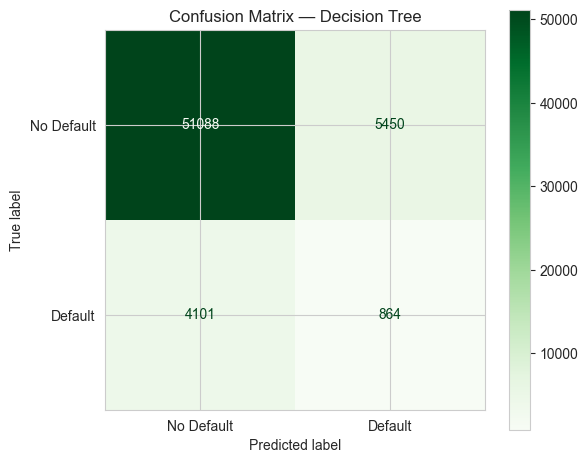

True Negatives (correctly approved): 51088
False Positives (safe applicant denied/flagged): 5450
False Negatives (defaulter approved — costliest error): 4101
True Positives (correctly denied/flagged defaulter): 864


In [7]:
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot(ax=ax, cmap="Greens")
ax.set_title("Confusion Matrix — Decision Tree")
plt.tight_layout()
plt.show()

print(f"True Negatives (correctly approved): {tn}")
print(f"False Positives (safe applicant denied/flagged): {fp}")
print(f"False Negatives (defaulter approved — costliest error): {fn}")
print(f"True Positives (correctly denied/flagged defaulter): {tp}")

In [8]:
report = classification_report(y_test, y_test_pred, target_names=["No Default", "Default"])
print(report)

              precision    recall  f1-score   support

  No Default       0.93      0.90      0.91     56538
     Default       0.14      0.17      0.15      4965

    accuracy                           0.84     61503
   macro avg       0.53      0.54      0.53     61503
weighted avg       0.86      0.84      0.85     61503



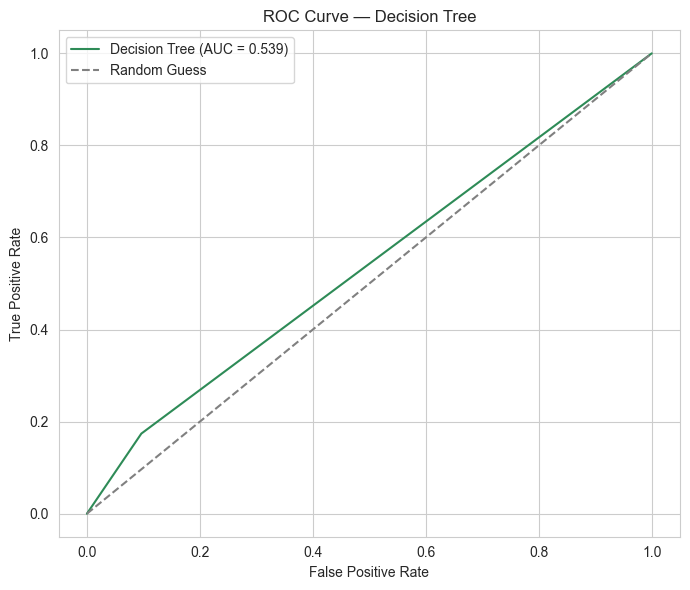

Observation: AUC of 0.539 means the model correctly ranks a random defaulter above a random non-defaulter 53.9% of the time.


In [9]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
auc = roc_auc_score(y_test, y_test_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, label=f"Decision Tree (AUC = {auc:.3f})", color="seagreen")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
ax.set_title("ROC Curve — Decision Tree")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Observation: AUC of {auc:.3f} means the model correctly ranks a random "
      f"defaulter above a random non-defaulter {auc*100:.1f}% of the time.")

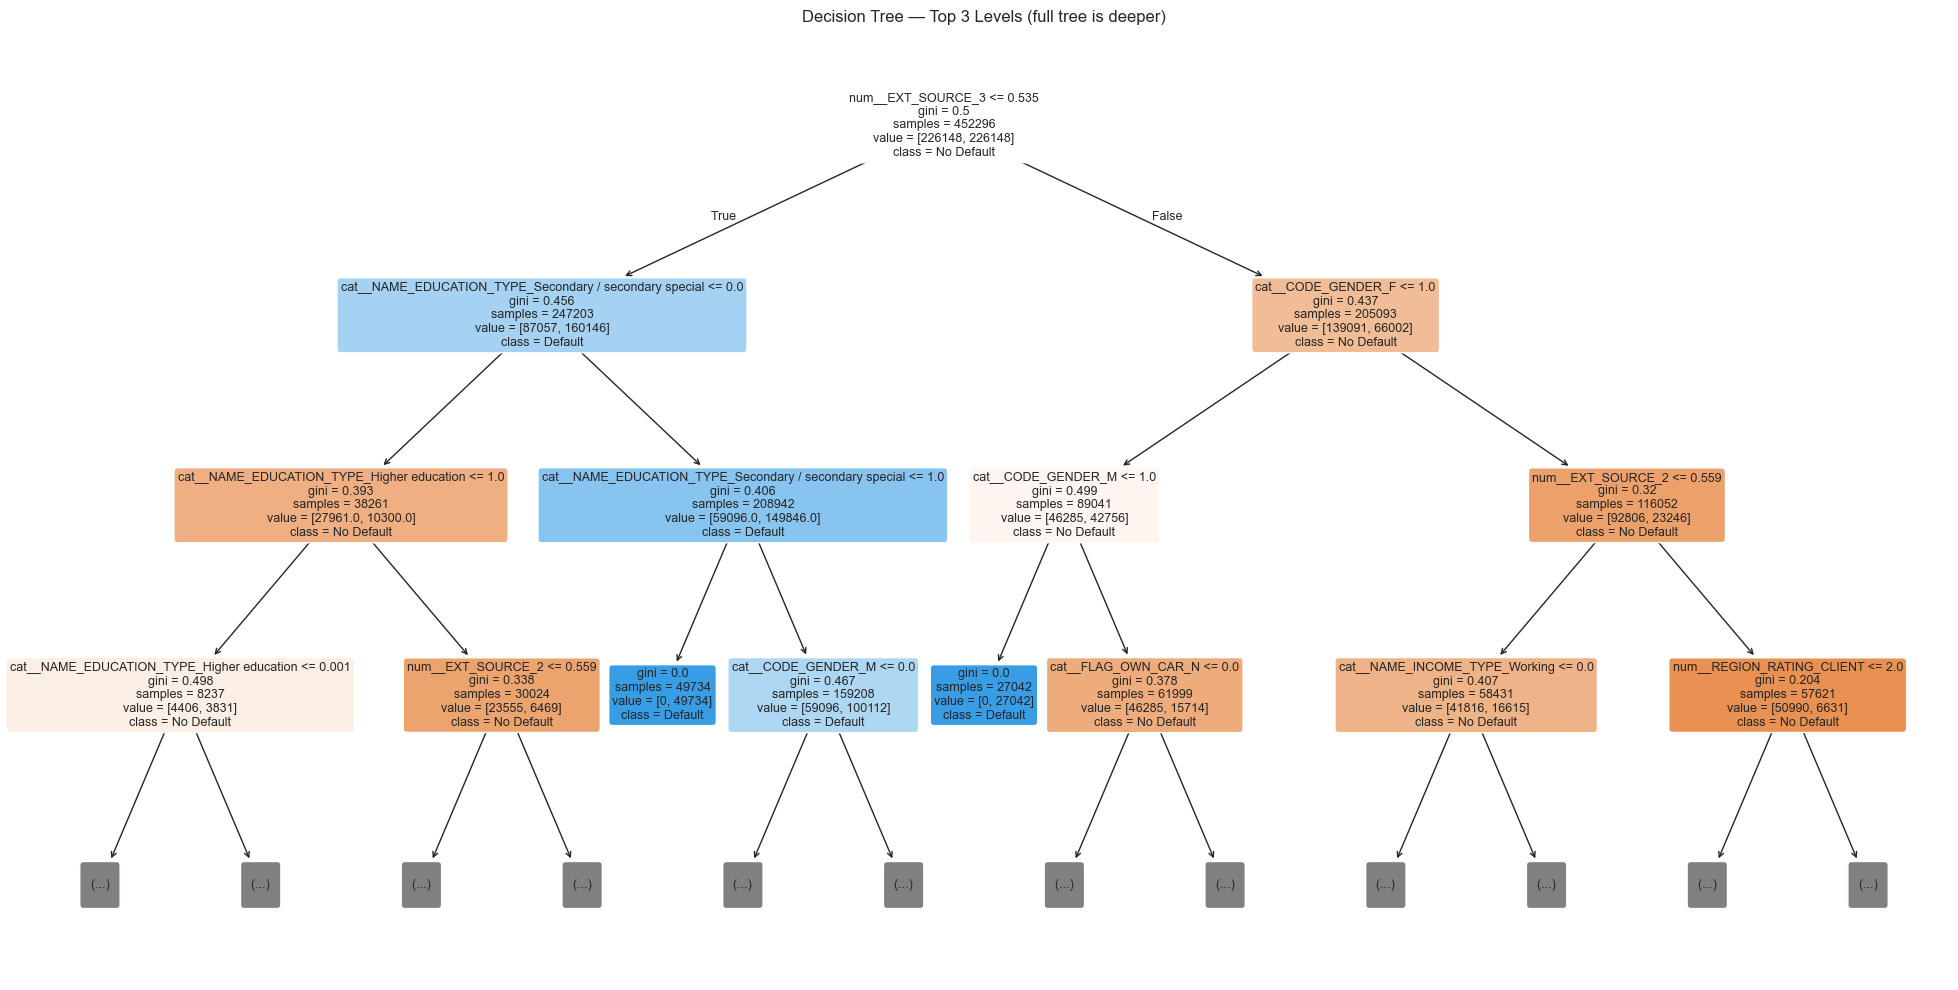

Observation: root node splits on 'num__EXT_SOURCE_3' — the single most discriminating feature for the whole dataset. Root and internal nodes are decision rules; leaf nodes are the final predicted class.


In [10]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    model, max_depth=3, feature_names=X_train.columns, class_names=["No Default", "Default"],
    filled=True, rounded=True, fontsize=9, ax=ax,
)
ax.set_title("Decision Tree — Top 3 Levels (full tree is deeper)")
plt.tight_layout()
plt.show()

print(f"Observation: root node splits on '{X_train.columns[model.tree_.feature[0]]}' — "
      f"the single most discriminating feature for the whole dataset. Root and "
      f"internal nodes are decision rules; leaf nodes are the final predicted class.")

,Feature,Importance
20,cat__CODE_GENDER_M,0.122339
4,cat__NAME_EDUCATION_TYPE_Secondary / secondary...,0.115354
108,num__EXT_SOURCE_3,0.115121
19,cat__CODE_GENDER_F,0.086455
12,cat__NAME_INCOME_TYPE_Working,0.076485
99,cat__FLAG_OWN_CAR_Y,0.065214
109,num__EXT_SOURCE_2,0.039526
146,num__CNT_FAM_MEMBERS,0.028305
148,num__AMT_REQ_CREDIT_BUREAU_YEAR,0.021109
144,num__REG_CITY_NOT_WORK_CITY,0.018426


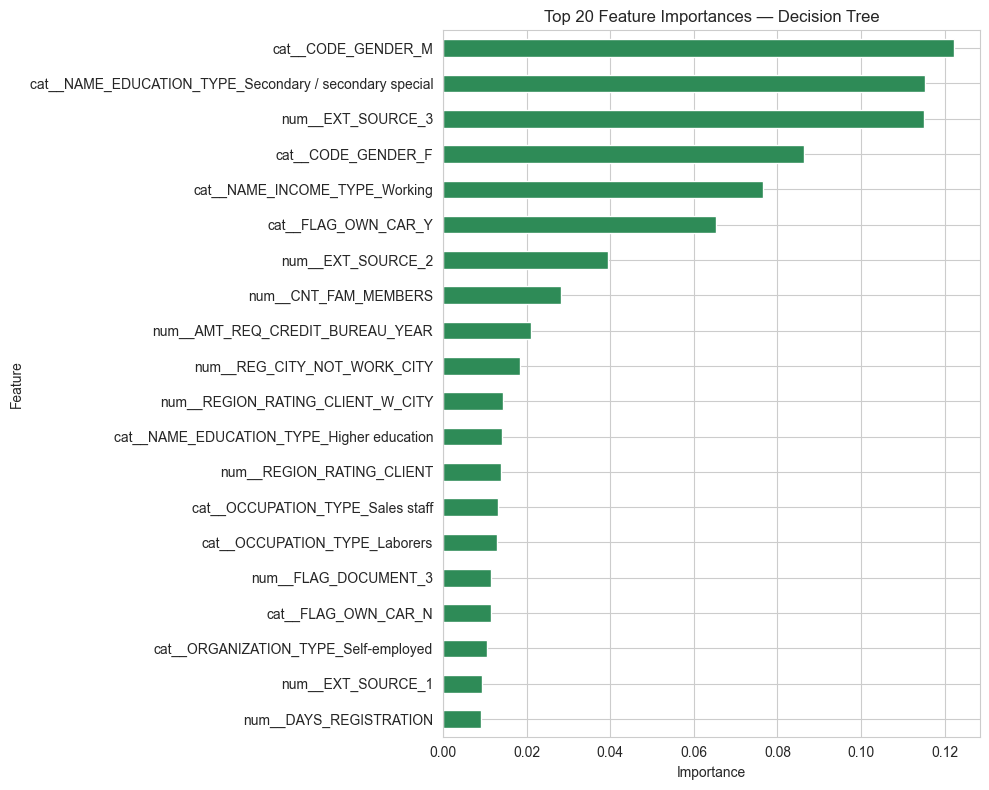

Observation: 'cat__CODE_GENDER_M' is the single most influential feature for predicting default in this tree.


In [11]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_,
}).sort_values("Importance", ascending=False)

top20 = importance_df.head(20)
display(top20)

fig, ax = plt.subplots(figsize=(10, 8))
top20.sort_values("Importance").plot(x="Feature", y="Importance", kind="barh", ax=ax,
                                       color="seagreen", legend=False)
ax.set_title("Top 20 Feature Importances — Decision Tree")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print(f"Observation: '{top20.iloc[0]['Feature']}' is the single most influential "
      f"feature for predicting default in this tree.")

In [12]:
model_dir = PROJECT_DIR / "models"
model_dir.mkdir(parents=True, exist_ok=True)

try:
    joblib.dump(model, model_dir / "decision_tree_model.pkl")
    print("Model saved to", model_dir / "decision_tree_model.pkl")
except OSError as exc:
    raise OSError(f"Could not save model to {model_dir}") from exc

Model saved to E:\Credit Risk Assessment System\models\decision_tree_model.pkl
